In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/kaggle/input/datasets/andradaolteanu/kaggle-data-science-survey-20172021/kaggle_survey_2017_2021.csv')

/tmp/ipykernel_17/2313828645.py:1: DtypeWarning: Columns (0,1,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266

In [3]:
df.head()

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
0,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106302 entries, 0 to 106301
Columns: 293 entries, - to Q38_B_OTHER
dtypes: object(293)
memory usage: 237.6+ MB


In [5]:
df.describe()

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
count,106302,89586,105857,106207,106181,103319,99088,92786,65943,20885,...,2212,2761,1128,1022,7439,1287,1218,1186,1,629
unique,7,12778,12,10,78,13,36,21,2,2,...,2,2,2,2,2,2,2,2,1,2
top,2021,394,25-29,Male,India,Masterâ€™s degree,Student,3-5 years,Python,R,...,Neptune.ai,Weights & Biases,Comet.ml,Sacred + Omniboard,TensorBoard,Guild.ai,Polyaxon,Domino Model Monitor,"In the next 2 years, do you hope to become mor...",Other
freq,23926,105,23748,49178,25192,37395,21242,15995,65942,20884,...,2211,2760,1127,1021,7438,1286,1217,1185,1,628


In [6]:
df.isnull().sum()

-                                           0
Time from Start to Finish (seconds)     16716
Q1                                        445
Q2                                         95
Q3                                        121
                                        ...  
Q38_B_Part_6                           105015
Q38_B_Part_7                           105084
Q38_B_Part_9                           105116
Q38_B_Part_11                          106301
Q38_B_OTHER                            105673
Length: 293, dtype: int64

## Handle Missing Values

There are 3 types of missing values:

Completely empty rows → Remove

Optional survey answers → Keep

Important columns missing → Fill or drop

In [7]:
print(df.columns[:25].tolist())

['-', 'Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3', 'Q7_Part_4', 'Q7_Part_5', 'Q7_Part_6', 'Q7_Part_7', 'Q7_Part_8', 'Q7_Part_9', 'Q7_Part_10', 'Q7_Part_11', 'Q7_Part_12', 'Q7_OTHER', 'Q8', 'Q9_Part_1', 'Q9_Part_2', 'Q9_Part_3']


In [8]:
# Drop rows where Age or Gender is missing
df = df.dropna(subset=["Q1", "Q2"])
df['age']=df['Q1']
df['gender']=df['Q2']
# Fill missing education with 'Unknown'
df["Education"] = df["Q4"].fillna("Unknown")

## Clean Age Column


We convert age ranges into numeric average.

In [9]:
def convert_age_range(age):
    if "-" in str(age):
        start, end = age.split("-")
        return (int(start) + int(end)) / 2
    return np.nan

df["Age_numeric"] = df["age"].apply(convert_age_range)

## Clean Years of Coding



In [10]:
def convert_experience(exp):
    if "20+" in str(exp):
        return 20
    if "-" in str(exp):
        start, end = exp.split("-")
        return (int(start) + int(end.split()[0])) / 2
    return np.nan

df["Experience_numeric"] = df["Q6"].apply(convert_experience)

## Categorical Handling (Label Encoding / Mapping)

We convert text categories into numbers.

### Gender Encoding

In [11]:
gender_map = {
    "Man": 0,
    "Woman": 1,
    "Non-binary": 2
}

df["Gender_encoded"] = df["gender"].map(gender_map)

### Education Level Encoding

* Bachelor's degree: 1,
* Master's degree: 2,
* Doctoral degree: 3,
* Professional degree: 4,
* Unknown: 0



In [12]:

edu_map = {
    "Bachelor's degree": 1,
    "Master's degree": 2,
    "Doctoral degree": 3,
    "Professional degree": 4,
    "Unknown": 0
}

df["Education_encoded"] = df["Education"].map(edu_map)

## Multi-Select Columns (Programming Languages)

Convert into dummy variables:

Now each language becomes a column:

* Python (0/1)

* R (0/1)

* SQL (0/1)

In [13]:
lang_cols = [col for col in df.columns if "Q7_" in col]

print(lang_cols)
print("Total language columns:", len(lang_cols))

['Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3', 'Q7_Part_4', 'Q7_Part_5', 'Q7_Part_6', 'Q7_Part_7', 'Q7_Part_8', 'Q7_Part_9', 'Q7_Part_10', 'Q7_Part_11', 'Q7_Part_12', 'Q7_OTHER']
Total language columns: 13


### Remove Header Row

In [14]:
print(df[lang_cols].head(2))

                                           Q7_Part_1  \
0  What programming languages do you use on a reg...   
1                                             Python   

                                           Q7_Part_2  \
0  What programming languages do you use on a reg...   
1                                                  R   

                                           Q7_Part_3  \
0  What programming languages do you use on a reg...   
1                                                NaN   

                                           Q7_Part_4  \
0  What programming languages do you use on a reg...   
1                                                NaN   

                                           Q7_Part_5  \
0  What programming languages do you use on a reg...   
1                                                NaN   

                                           Q7_Part_6  \
0  What programming languages do you use on a reg...   
1                                          

In [15]:
df = df.iloc[1:].reset_index(drop=True)

In [16]:
for col in lang_cols:
    df[col] = df[col].notna().astype(int)

In [17]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER,age,gender,Education,Age_numeric,Experience_numeric,Gender_encoded,Education_encoded
0,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,1,1,...,NaN,NaN,NaN,50-54,Man,Bachelorâ€™s degree,52.0,7.5,0.0,NaN
1,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,0,0,...,NaN,NaN,NaN,50-54,Man,Masterâ€™s degree,52.0,20.0,0.0,NaN
2,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,1,0,...,NaN,NaN,NaN,22-24,Man,Masterâ€™s degree,23.0,2.0,0.0,NaN
3,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,1,0,...,NaN,NaN,NaN,45-49,Man,Doctoral degree,47.0,20.0,0.0,3.0
4,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,1,0,...,NaN,NaN,NaN,45-49,Man,Doctoral degree,47.0,NaN,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105830,2017,NaN,22-24,Male,People 's Republic of China,Bachelor's degree,NaN,NaN,0,0,...,NaN,NaN,NaN,22-24,Male,Bachelor's degree,23.0,NaN,NaN,1.0
105831,2017,NaN,22-24,Female,Other,Master's degree,NaN,Less than a year,0,0,...,NaN,NaN,NaN,22-24,Female,Master's degree,23.0,NaN,NaN,2.0
105832,2017,NaN,25-29,Male,Indonesia,Bachelor's degree,Programmer,1 to 2 years,0,0,...,NaN,NaN,NaN,25-29,Male,Bachelor's degree,27.0,NaN,NaN,1.0
105833,2017,NaN,25-29,Female,Taiwan,NaN,NaN,NaN,0,0,...,NaN,NaN,NaN,25-29,Female,Unknown,27.0,NaN,NaN,0.0


### Rename columns

In [18]:
# 1. Define your map: {New Name: Original Column}
lang_map = {
    'python': 'Q7_Part_1',
    'r': 'Q7_Part_2',
    'sql': 'Q7_Part_3',
    'c': 'Q7_Part_4',
    'c++': 'Q7_Part_5',
    'java': 'Q7_Part_6',
    'javascript': 'Q7_Part_7',
    'julia': 'Q7_Part_8',
    'swift': 'Q7_Part_9',
    'bash': 'Q7_Part_10',
    'matlab': 'Q7_Part_11',
    'none': 'Q7_Part_12',
    'other': 'Q7_OTHER'
}

# 2. Use a loop to create the new columns
for new_name, old_col in lang_map.items():
    df[new_name] = df[old_col]

In [19]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,c,c++,java,javascript,julia,swift,bash,matlab,none,other
0,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,0,0,...,1,1,1,0,0,0,0,0,0,0
2,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,1,0,...,0,1,1,0,0,0,0,0,0,0
3,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,1,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105830,2017,NaN,22-24,Male,People 's Republic of China,Bachelor's degree,NaN,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0
105831,2017,NaN,22-24,Female,Other,Master's degree,NaN,Less than a year,0,0,...,0,0,0,0,0,0,0,0,0,0
105832,2017,NaN,25-29,Male,Indonesia,Bachelor's degree,Programmer,1 to 2 years,0,0,...,0,0,0,0,0,0,0,0,0,0
105833,2017,NaN,25-29,Female,Taiwan,NaN,NaN,NaN,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
lang_cols = [col for col in df.columns]

In [21]:
lang_cols

['-',
 'Time from Start to Finish (seconds)',
 'Q1',
 'Q2',
 'Q3',
 'Q4',
 'Q5',
 'Q6',
 'Q7_Part_1',
 'Q7_Part_2',
 'Q7_Part_3',
 'Q7_Part_4',
 'Q7_Part_5',
 'Q7_Part_6',
 'Q7_Part_7',
 'Q7_Part_8',
 'Q7_Part_9',
 'Q7_Part_10',
 'Q7_Part_11',
 'Q7_Part_12',
 'Q7_OTHER',
 'Q8',
 'Q9_Part_1',
 'Q9_Part_2',
 'Q9_Part_3',
 'Q9_Part_5',
 'Q9_Part_6',
 'Q9_Part_7',
 'Q9_Part_8',
 'Q9_Part_9',
 'Q9_Part_10',
 'Q9_Part_12',
 'Q9_OTHER',
 'Q10_Part_1',
 'Q10_Part_2',
 'Q10_Part_3',
 'Q10_Part_4',
 'Q10_Part_5',
 'Q10_Part_6',
 'Q10_Part_7',
 'Q10_Part_8',
 'Q10_Part_9',
 'Q10_Part_10',
 'Q10_Part_11',
 'Q10_Part_12',
 'Q10_Part_16',
 'Q10_OTHER',
 'Q11',
 'Q12new',
 'Q12_Part_1',
 'Q12_Part_2',
 'Q12_Part_5',
 'Q12_OTHER',
 'Q13',
 'Q14_Part_1',
 'Q14_Part_2',
 'Q14_Part_3',
 'Q14_Part_4',
 'Q14_Part_5',
 'Q14_Part_6',
 'Q14_Part_7',
 'Q14_Part_8',
 'Q14_Part_9',
 'Q14_Part_10',
 'Q14_Part_11',
 'Q14_OTHER',
 'Q15',
 'Q16_Part_1',
 'Q16_Part_2',
 'Q16_Part_3',
 'Q16_Part_4',
 'Q16_Part_5',
 'Q

# Insights
## Most Popular Programming Languages

In [22]:
language_cols = [
    'python','r','sql','c','c++','java',
    'javascript','julia','swift','bash',
    'matlab','none','other'
]

language_usage = df[language_cols].sum().sort_values(ascending=False)
print(language_usage)

python        65942
sql           33090
r             20884
java          14402
javascript    12750
c++           11618
c              9696
matlab         9320
bash           8737
other          6292
julia           797
swift           440
none              0
dtype: int64


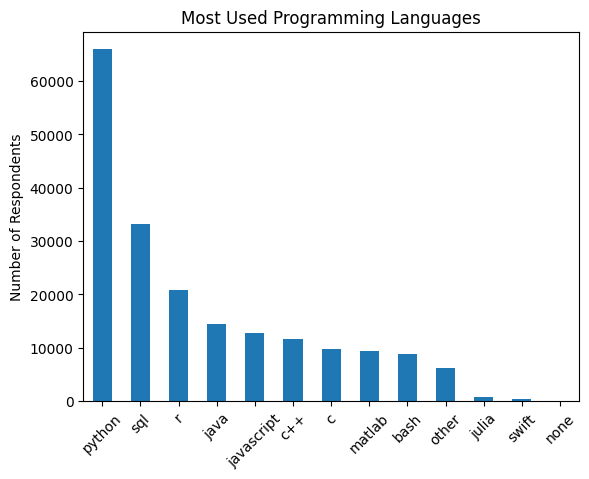

In [23]:
import matplotlib.pyplot as plt

language_usage.plot(kind='bar')
plt.title("Most Used Programming Languages")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.show()

In [24]:
percentage_usage = (language_usage / len(df)) * 100
print(percentage_usage)

python        62.306420
sql           31.265649
r             19.732603
java          13.607975
javascript    12.047054
c++           10.977465
c              9.161431
matlab         8.806161
bash           8.255303
other          5.945103
julia          0.753059
swift          0.415741
none           0.000000
dtype: float64


## Average Number of Languages Per Person

In [25]:
df["total_languages"] = df[language_cols].sum(axis=1)

print("Average languages used per respondent:",
      df["total_languages"].mean())

Average languages used per respondent: 1.8327396418954032


Most data professionals use multiple languages regularly.

## Age Distribution

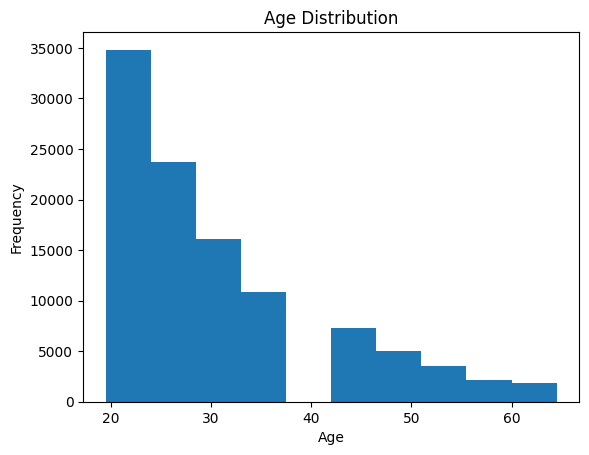

In [26]:
df["Age_numeric"].plot(kind="hist", bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

## Experience Distribution

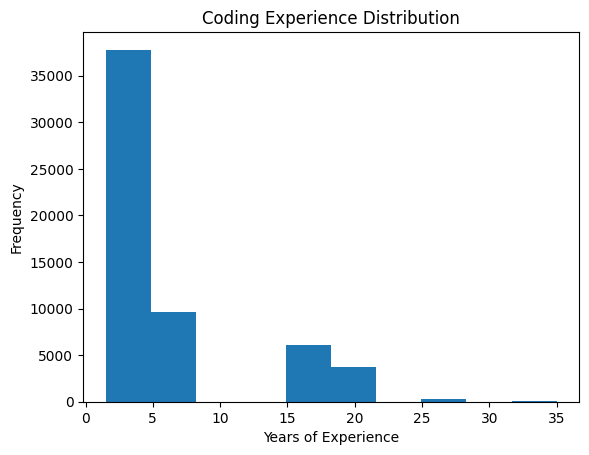

In [27]:
df["Experience_numeric"].plot(kind="hist", bins=10)
plt.title("Coding Experience Distribution")
plt.xlabel("Years of Experience")
plt.show()

Most respondents have early to starting or mid career experience.

## Age vs Experience

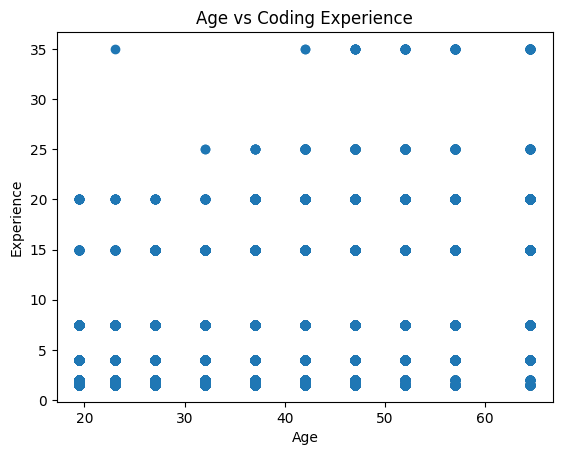

In [28]:
plt.scatter(df["Age_numeric"], df["Experience_numeric"])
plt.title("Age vs Coding Experience")
plt.xlabel("Age")
plt.ylabel("Experience")
plt.show()

older respondents → more experience.

## Python Usage by Education

In [29]:
python_by_edu = df.groupby("Education")["python"].mean().sort_values(ascending=False)
print(python_by_edu)

Education
Professional doctorate                                                 0.833333
Bachelorâ€™s degree                                                    0.754848
Masterâ€™s degree                                                      0.753684
Some college/university study without earning a bachelorâ€™s degree    0.706759
Doctoral degree                                                        0.631447
No formal education past high school                                   0.612299
I prefer not to answer                                                 0.596501
Professional degree                                                    0.548428
Bachelor's degree                                                      0.000000
I did not complete any formal education past high school               0.000000
Master's degree                                                        0.000000
Some college/university study without earning a bachelor's degree      0.000000
Unknown                       

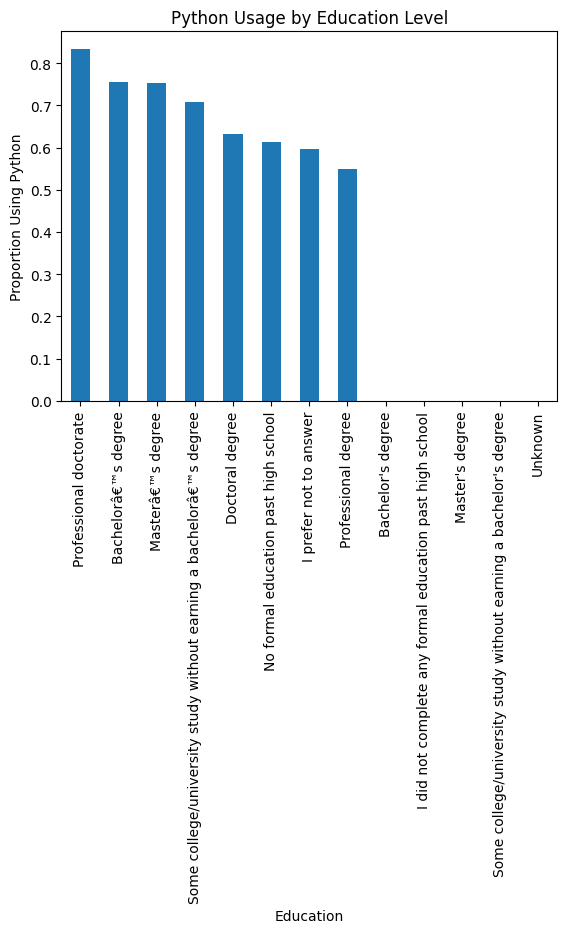

In [30]:
python_by_edu.plot(kind='bar')
plt.title("Python Usage by Education Level")
plt.ylabel("Proportion Using Python")
plt.show()

## Gender Distribution

In [31]:
# 1. Define the mapping (handles different cases and variations)
gender_mapping = {
    'male': 'Man',
    'man': 'Man',
    'Male': 'Man',
    'female': 'Woman',
    'woman': 'Woman',
    'Female': 'Woman'
}

# 2. Apply the replacement
df['gender'] = df['gender'].replace(gender_mapping)

Text(0, 0.5, '')

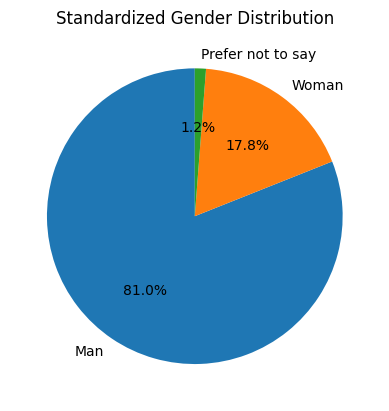

In [32]:
df['gender'].value_counts().head(3).plot(kind='pie', autopct="%1.1f%%", startangle=90)
plt.title("Standardized Gender Distribution")
plt.ylabel("")

## Language Correlation Heatmap

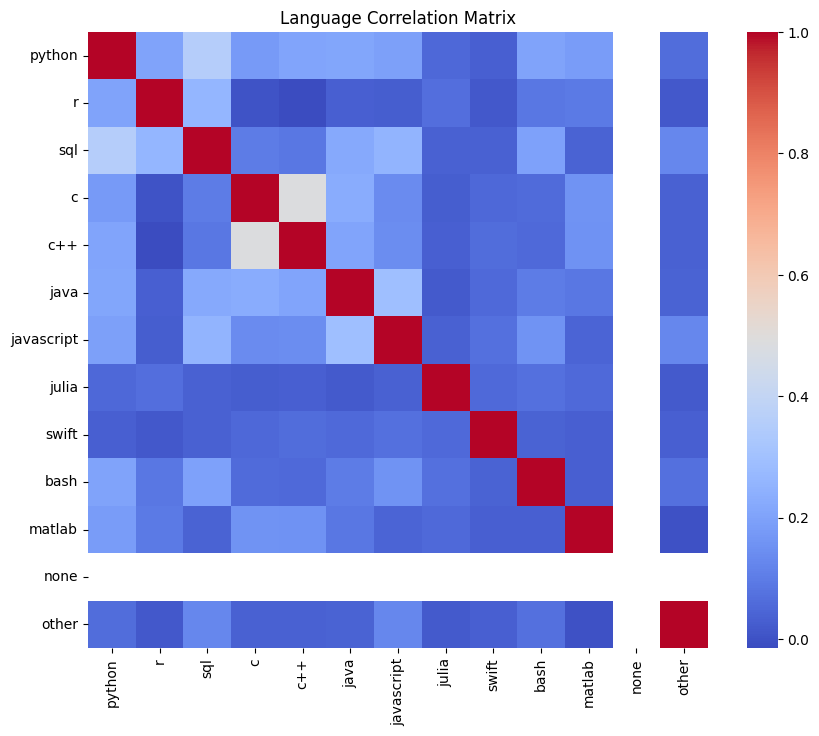

In [33]:
import seaborn as sns

corr = df[language_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Language Correlation Matrix")
plt.show()

## Meaning full columns

export to csv for POWER BI dashboard

In [34]:
# 1. Define the list of columns you actually care about
meaningful_cols = [
    'age', 'gender', 'Education',
    'Age_numeric', 'Experience_numeric',
    'Gender_encoded', 'Education_encoded',
    'python', 'r', 'sql', 'c', 'c++', 'java',
    'javascript', 'julia', 'swift', 'bash', 'matlab', 'none', 'other'
]

# 2. Overwrite the dataframe with only these columns
df_meaningfull = df[meaningful_cols]

In [35]:
df_meaningfull.to_csv('cleaned_servey_data.csv')